In [7]:
# Import necessary libraries
import cv2
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt

# Function to process and detect objects
def detect_objects(image_path):
    # Load YOLO
    net = cv2.dnn.readNet("yolov3.weights", "yolov3.cfg")
    layer_names = net.getLayerNames()
    output_layers = [layer_names[i - 1] for i in net.getUnconnectedOutLayers()]

    # Load class names
    with open("coco.names", "r") as f:
        classes = [line.strip() for line in f.readlines()]

    # Load image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    height, width, channels = img.shape

    # Prepare image for YOLO
    blob = cv2.dnn.blobFromImage(img, 0.00392, (416, 416), (0, 0, 0), True, crop=False)
    net.setInput(blob)
    outs = net.forward(output_layers)

    # Process detection
    class_ids = []
    confidences = []
    boxes = []

    for out in outs:
        for detection in out:
            scores = detection[5:]
            class_id = np.argmax(scores)
            confidence = scores[class_id]
            if confidence > 0.5:  # Confidence threshold
                # Object detected
                center_x = int(detection[0] * width)
                center_y = int(detection[1] * height)
                w = int(detection[2] * width)
                h = int(detection[3] * height)

                # Rectangle coordinates
                x = int(center_x - w / 2)
                y = int(center_y - h / 2)

                boxes.append([x, y, w, h])
                confidences.append(float(confidence))
                class_ids.append(class_id)

    # Non-max suppression
    indexes = cv2.dnn.NMSBoxes(boxes, confidences, 0.5, 0.4)

    # Draw bounding boxes
    colors = np.random.uniform(0, 255, size=(len(classes), 3))
    font = cv2.FONT_HERSHEY_PLAIN

    for i in range(len(boxes)):
        if i in indexes:
            x, y, w, h = boxes[i]
            label = str(classes[class_ids[i]])
            confidence = confidences[i]
            color = colors[class_ids[i]]

            # Draw rectangle and label
            cv2.rectangle(img, (x, y), (x + w, y + h), color, 2)
            cv2.putText(img, f"{label} {confidence:.2f}", (x, y - 10), font, 1, color, 2)

    return img

In [9]:
!wget https://pjreddie.com/media/files/yolov3.weights
!wget https://raw.githubusercontent.com/pjreddie/darknet/master/cfg/yolov3.cfg
!wget https://raw.githubusercontent.com/pjreddie/darknet/master/data/coco.names

--2025-04-01 13:45:44--  https://pjreddie.com/media/files/yolov3.weights
Resolving pjreddie.com (pjreddie.com)... 162.0.215.52
Connecting to pjreddie.com (pjreddie.com)|162.0.215.52|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 248007048 (237M) [application/octet-stream]
Saving to: ‘yolov3.weights’

yolov3.weights      100%[===================>] 236.52M  14.1MB/s    in 19s     

2025-04-01 13:46:04 (12.3 MB/s) - ‘yolov3.weights’ saved [248007048/248007048]

--2025-04-01 13:46:04--  https://raw.githubusercontent.com/pjreddie/darknet/master/cfg/yolov3.cfg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8342 (8.1K) [text/plain]
Saving to: ‘yolov3.cfg’

yolov3.cfg          100%[===================>]   8.15K  --.-KB/s    in 0s      

2

Saving Benefits-of-Owning-Multiple-Pets.jpg to Benefits-of-Owning-Multiple-Pets.jpg


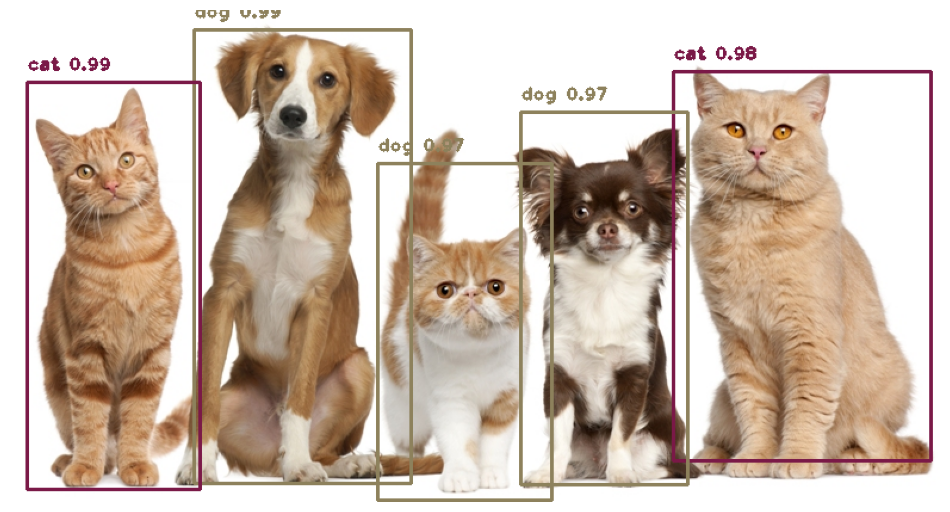

In [15]:
# Upload new image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Process image and detect objects
result = detect_objects(image_path)

# Display result
plt.figure(figsize=(12, 8))
plt.imshow(result)
plt.axis('off')
plt.show()